# Custom Dataset Depth Map Arm Boxes

This notebook first segments the whole user from the depth map, derives a tight full-user bounding box, and then places two slim arm boxes from that geometry.

The dataset does not provide per-frame boxes, so the notebook uses the foreground silhouette as a depth-only fallback. If you already have a reliable person detector, you can swap that in and keep the arm-box geometry unchanged.


---
## 1. Imports and helpers

The helper functions below discover a clip, isolate the whole user, estimate a full-user box, and place two slim arm boxes from it.


In [136]:
import json
import sys
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage as ndi

SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import DEPTH_RAW_H, DEPTH_RAW_W

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'plasma'

DATA_ROOT = Path('..') / 'customDataset'
DEFAULT_CLIP = DATA_ROOT / '0504_2033_90'

USER_CLOSE_ITERATIONS = 2
USER_OPEN_ITERATIONS = 1
USER_MORPH_SIZE = 5
USER_TOP_CROP_FRAC = 0.20
USER_BOTTOM_TRIM_FRAC = 0.02
ARM_LATERAL_OFFSET_FRAC = 0.28
ARM_BOX_WIDTH_FRAC = 0.33
ARM_BOX_MIN_WIDTH = 24
ARM_BOX_MAX_WIDTH = 120
HAND_CLOSE_PERCENTILE = 8
HAND_MIN_PIXELS = 160 # change this
HAND_MORPH_SIZE = 3
HAND_CENTER_STRIP_FRAC = 0.18
HAND_MAX_Y_FRAC = 0.85
HAND_EDGE_WEIGHT = 20.0
HAND_CENTER_PENALTY = 15.0
HAND_PAD_X_PX = 4
HAND_PAD_Y_PX = 4
ARM_PAD_X_PX = 2
ARM_PAD_Y_PX = 2
HAND_NO_DATA_DILATION_PX = 60 # this is to help with cases where the hand is very close to the camera and has a lot of missing depth values


def discover_clip_dirs(root: Path):
    clip_dirs = sorted({p.parent for p in root.rglob('*_Depth_640x480.png')})
    if clip_dirs:
        return clip_dirs
    return sorted({p.parent for p in root.rglob('*.png')})


def load_depth_clip(clip_dir: Path):
    frame_paths = sorted(clip_dir.glob('*_Depth_640x480.png'))
    if not frame_paths:
        frame_paths = sorted(clip_dir.glob('*depth*.png'))
    frames = [np.array(Image.open(path), dtype=np.float32) for path in frame_paths]
    if not frames:
        raise FileNotFoundError(f'No depth PNGs found in {clip_dir}')
    return np.stack(frames, axis=0), frame_paths


def bbox_from_mask(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    x1 = int(xs.min())
    x2 = int(xs.max()) + 1
    y1 = int(ys.min())
    y2 = int(ys.max()) + 1
    return x1, y1, x2, y2


def clamp_bbox(x1, y1, x2, y2, width=DEPTH_RAW_W, height=DEPTH_RAW_H):
    x1 = max(0, min(int(x1), width - 1))
    y1 = max(0, min(int(y1), height - 1))
    x2 = max(x1 + 1, min(int(x2), width))
    y2 = max(y1 + 1, min(int(y2), height))
    return x1, y1, x2, y2


def expand_bbox(bbox, pad_x=ARM_PAD_X_PX, pad_y=ARM_PAD_Y_PX):
    x1, y1, x2, y2 = bbox
    return clamp_bbox(x1 - pad_x, y1 - pad_y, x2 + pad_x, y2 + pad_y)


def otsu_threshold(values: np.ndarray, nbins: int = 256):
    values = values[np.isfinite(values) & (values > 0)]
    if values.size == 0:
        return None

    vmin = float(values.min())
    vmax = float(values.max())
    if vmin == vmax:
        return vmax

    hist, bin_edges = np.histogram(values, bins=min(nbins, max(2, int(vmax - vmin) + 1)), range=(vmin, vmax))
    hist = hist.astype(np.float64)
    if hist.sum() == 0:
        return None

    prob = hist / hist.sum()
    cumulative_prob = np.cumsum(prob)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    cumulative_mean = np.cumsum(prob * bin_centers)
    global_mean = cumulative_mean[-1]

    denominator = cumulative_prob * (1.0 - cumulative_prob)
    numerator = (global_mean * cumulative_prob - cumulative_mean) ** 2
    sigma_between = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator > 0)
    best_index = int(np.argmax(sigma_between))
    return float(bin_centers[best_index])


def foreground_mask(depth: np.ndarray):
    valid_mask = np.isfinite(depth) & (depth > 0)
    if not np.any(valid_mask):
        return valid_mask

    threshold = otsu_threshold(depth[valid_mask])
    if threshold is None:
        mask = valid_mask
    else:
        mask = valid_mask & (depth <= threshold)
        if np.count_nonzero(mask) < 500:
            lower_cut = np.percentile(depth[valid_mask], 35)
            mask = valid_mask & (depth <= lower_cut)

    structure = np.ones((USER_MORPH_SIZE, USER_MORPH_SIZE), dtype=bool)
    mask = ndi.binary_closing(mask, structure=structure, iterations=USER_CLOSE_ITERATIONS)
    mask = ndi.binary_opening(mask, structure=structure, iterations=USER_OPEN_ITERATIONS)
    mask = ndi.binary_fill_holes(mask)
    return mask


def largest_connected_component(mask: np.ndarray):
    labels, num_labels = ndi.label(mask)
    if num_labels == 0:
        return mask

    counts = np.bincount(labels.ravel())
    counts[0] = 0
    largest_label = int(counts.argmax())
    return labels == largest_label


def estimate_user_box(depth: np.ndarray):
    mask = foreground_mask(depth)
    user_mask = largest_connected_component(mask)
    user_bbox = bbox_from_mask(user_mask)

    if user_bbox is None:
        return clamp_bbox(0, 0, DEPTH_RAW_W, DEPTH_RAW_H), user_mask

    return user_bbox, user_mask


def make_arm_box(user_bbox, user_center_x, direction):
    x1, y1, x2, y2 = user_bbox
    user_width = x2 - x1
    user_height = y2 - y1

    arm_half_width = int(user_width * ARM_BOX_WIDTH_FRAC / 2)
    arm_half_width = max(ARM_BOX_MIN_WIDTH // 2, min(ARM_BOX_MAX_WIDTH // 2, arm_half_width))

    lateral_offset = max(arm_half_width + 2, int(user_width * ARM_LATERAL_OFFSET_FRAC))
    if direction == 'left':
        anchor_x = int(user_center_x - lateral_offset)
    else:
        anchor_x = int(user_center_x + lateral_offset)

    arm_y1 = y1 + int(user_height * USER_TOP_CROP_FRAC)
    arm_y2 = y2 - int(user_height * USER_BOTTOM_TRIM_FRAC)
    if arm_y2 <= arm_y1:
        arm_y2 = y2

    return clamp_bbox(anchor_x - arm_half_width, arm_y1, anchor_x + arm_half_width, arm_y2)


def estimate_arm_boxes(depth: np.ndarray):
    user_bbox, user_mask = estimate_user_box(depth)
    x1, y1, x2, y2 = user_bbox

    user_center_x = (x1 + x2) / 2.0
    left_box = make_arm_box(user_bbox, user_center_x, 'left')
    right_box = make_arm_box(user_bbox, user_center_x, 'right')

    return expand_bbox(left_box), expand_bbox(right_box), user_bbox, user_mask


def estimate_hand_box(depth: np.ndarray, user_bbox=None, user_mask=None):
    if user_bbox is None or user_mask is None:
        user_bbox, user_mask = estimate_user_box(depth)

    user_values = depth[user_mask]
    user_values = user_values[np.isfinite(user_values) & (user_values > 0)]
    if user_values.size == 0:
        return None, user_bbox, user_mask

    user_x1, user_y1, user_x2, user_y2 = user_bbox
    user_width = max(1, user_x2 - user_x1)
    user_height = max(1, user_y2 - user_y1)
    user_center_x = (user_x1 + user_x2) / 2.0

    close_cut = np.percentile(user_values, HAND_CLOSE_PERCENTILE)
    hand_mask = user_mask & np.isfinite(depth) & (depth > 0) & (depth <= close_cut)

    structure = np.ones((HAND_MORPH_SIZE, HAND_MORPH_SIZE), dtype=bool)
    hand_mask = ndi.binary_closing(hand_mask, structure=structure, iterations=1)
    hand_mask = ndi.binary_opening(hand_mask, structure=structure, iterations=1)
    hand_mask = ndi.binary_fill_holes(hand_mask)
    
    # Dilate to include nearby no-data pixels (NaN regions from very close hands)
    dilation_structure = np.ones((HAND_NO_DATA_DILATION_PX, HAND_NO_DATA_DILATION_PX), dtype=bool)
    hand_mask_dilated = ndi.binary_dilation(hand_mask, structure=dilation_structure, iterations=1)
    # Expand search to dilated region, but stay within user mask
    hand_mask = hand_mask_dilated & user_mask

    labels, num_labels = ndi.label(hand_mask)
    if num_labels == 0:
        fallback_cut = np.percentile(user_values, 12)
        hand_mask = user_mask & np.isfinite(depth) & (depth > 0) & (depth <= fallback_cut)
        labels, num_labels = ndi.label(hand_mask)

    best_bbox = None
    best_score = None
    for label_idx in range(1, num_labels + 1):
        component = labels == label_idx
        pixel_count = int(component.sum())
        if pixel_count < HAND_MIN_PIXELS:
            continue
        bbox = bbox_from_mask(component)
        if bbox is None:
            continue

        ys, xs = np.where(component)
        centroid_x = float(xs.mean())
        centroid_y = float(ys.mean())
        if centroid_y > user_y1 + user_height * HAND_MAX_Y_FRAC:
            continue

        mean_depth = float(np.mean(depth[component]))
        center_distance = abs(centroid_x - user_center_x) / user_width
        center_penalty = HAND_CENTER_PENALTY if abs(centroid_x - user_center_x) < user_width * HAND_CENTER_STRIP_FRAC else 0.0
        score = (mean_depth + center_penalty - HAND_EDGE_WEIGHT * center_distance, -pixel_count)
        if best_score is None or score < best_score:
            best_score = score
            best_bbox = bbox

    if best_bbox is None:
        return None, user_bbox, user_mask

    return expand_bbox(best_bbox, pad_x=HAND_PAD_X_PX, pad_y=HAND_PAD_Y_PX), user_bbox, user_mask


def plot_arm_boxes(depth: np.ndarray, frame_title: str = ''):
    left_box, right_box, user_box, user_mask = estimate_arm_boxes(depth)
    hand_box, _, _ = estimate_hand_box(depth, user_box, user_mask)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(depth, cmap='plasma')

    for bbox, color, label in [
        (user_box, '#FFFFFF', 'user box'),
        (left_box, '#00E5FF', 'left arm box'),
        (right_box, '#FFB000', 'right arm box'),
        (hand_box, '#FF4D4D', 'hand box'),
    ]:
        if bbox is None:
            continue
        x1, y1, x2, y2 = bbox
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 8), label, color=color, fontsize=9, weight='bold', va='bottom')

    ax.set_title(frame_title or 'Depth frame with estimated user, arm, and hand boxes')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return left_box, right_box, hand_box, user_box, user_mask


def save_arm_annotations(clip_dir: Path, output_path: Path):
    frames, frame_paths = load_depth_clip(clip_dir)
    annotations = []
    for frame_path, frame in zip(frame_paths, frames):
        left_box, right_box, user_box, user_mask = estimate_arm_boxes(frame)
        hand_box, _, _ = estimate_hand_box(frame, user_box, user_mask)
        annotations.append({
            'frame': frame_path.name,
            'user_box': list(map(int, user_box)),
            'left_box': list(map(int, left_box)),
            'right_box': list(map(int, right_box)),
            'hand_box': list(map(int, hand_box)) if hand_box is not None else None,
        })
    output_path.write_text(json.dumps({
        'clip_dir': str(clip_dir),
        'annotations': annotations,
    }, indent=2))
    return output_path

In [142]:
# Batch export annotations for all clips under DATA_ROOT
clip_dirs = discover_clip_dirs(DATA_ROOT)
print(f'Found {len(clip_dirs)} clip folders; exporting annotations...')
for clip_dir in clip_dirs:
    try:
        out_path = Path('..') / 'customDataset' / f'{clip_dir.name}' / f'{clip_dir.name}_arm_boxes.json'
        # if out_path.exists():
        #     print(f'Skipping {clip_dir.name} (output exists)')
        #     continue
        save_arm_annotations(clip_dir, out_path)
        print(f'Saved annotations for {clip_dir.name} to {out_path}')
    except Exception as e:
        print(f'Error processing {clip_dir}: {e}')

Found 15 clip folders; exporting annotations...
Saved annotations for 0504_0007_80 to ..\customDataset\0504_0007_80\0504_0007_80_arm_boxes.json
Saved annotations for 0504_0140_90 to ..\customDataset\0504_0140_90\0504_0140_90_arm_boxes.json
Saved annotations for 0504_0153_90 to ..\customDataset\0504_0153_90\0504_0153_90_arm_boxes.json
Saved annotations for 0504_0204_90 to ..\customDataset\0504_0204_90\0504_0204_90_arm_boxes.json
Saved annotations for 0504_0206_90 to ..\customDataset\0504_0206_90\0504_0206_90_arm_boxes.json
Saved annotations for 0504_0208_90 to ..\customDataset\0504_0208_90\0504_0208_90_arm_boxes.json
Saved annotations for 0504_2017_90 to ..\customDataset\0504_2017_90\0504_2017_90_arm_boxes.json
Saved annotations for 0504_2019_90 to ..\customDataset\0504_2019_90\0504_2019_90_arm_boxes.json
Saved annotations for 0504_2020_90 to ..\customDataset\0504_2020_90\0504_2020_90_arm_boxes.json
Saved annotations for 0504_2021_90 to ..\customDataset\0504_2021_90\0504_2021_90_arm_box

---
## 2. Pick a clip and inspect the raw depth sequence

If you want a different sample, change `CLIP_DIR` in the next cell to another folder under `customDataset/`.


Found 15 clip folders under ..\customDataset
First few clips:
   ..\customDataset\0504_0007_80
   ..\customDataset\0504_0140_90
   ..\customDataset\0504_0153_90
   ..\customDataset\0504_0204_90
   ..\customDataset\0504_0206_90

Selected clip: ..\customDataset\0504_2033_90
Frame count: 90
Frame shape: (480, 640)
Depth range: [0.0, 239.0]


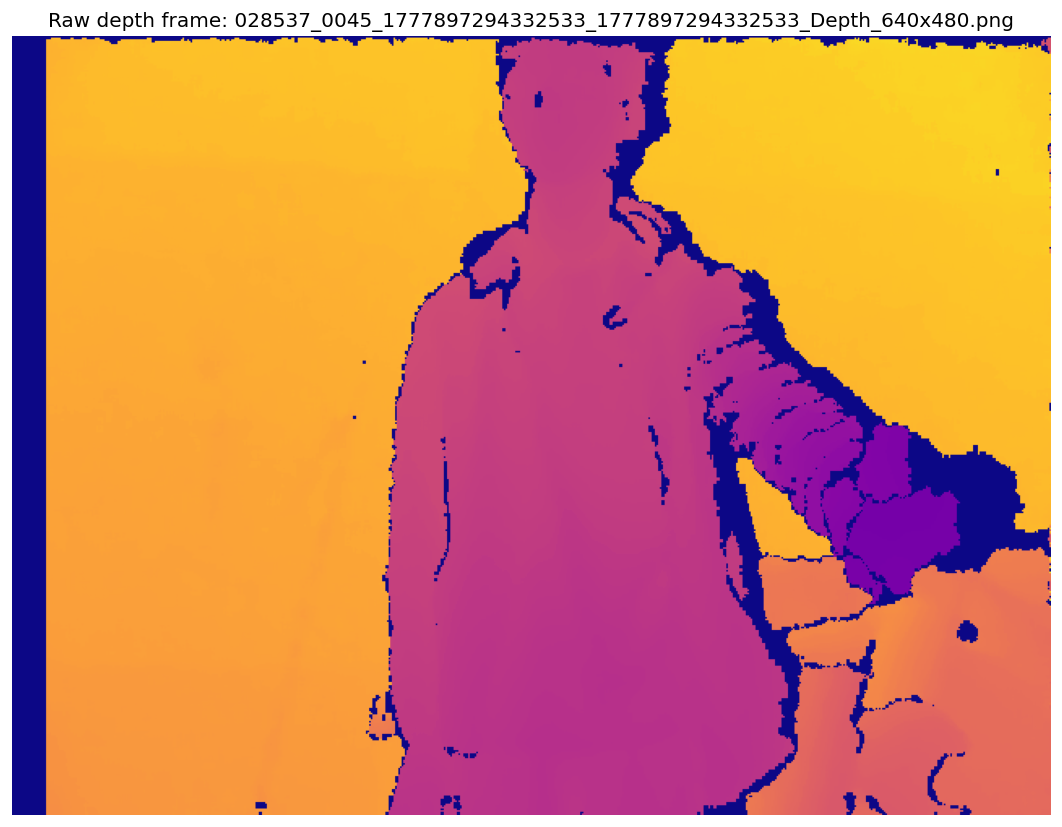


Contents of general_information.txt:
handReaching


In [137]:
clip_dirs = discover_clip_dirs(DATA_ROOT)
print(f'Found {len(clip_dirs)} clip folders under {DATA_ROOT}')
print('First few clips:')
for path in clip_dirs[:5]:
    print('  ', path)

CLIP_DIR = DEFAULT_CLIP if DEFAULT_CLIP.exists() else clip_dirs[0]
frames, frame_paths = load_depth_clip(CLIP_DIR)

print(f'\nSelected clip: {CLIP_DIR}')
print(f'Frame count: {len(frames)}')
print(f'Frame shape: {frames[0].shape}')
print(f'Depth range: [{frames.min():.1f}, {frames.max():.1f}]')

sample_idx = len(frames) // 2
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(frames[sample_idx], cmap='plasma')
ax.set_title(f'Raw depth frame: {frame_paths[sample_idx].name}')
ax.axis('off')
plt.tight_layout()
plt.show()

# print the text in general_information.txt for the selected clip
general_info_path = CLIP_DIR / 'general_information.txt'
if general_info_path.exists():
    print(f'\nContents of {general_info_path.name}:')
    print(general_info_path.read_text())


---
## 3. Estimate arm and hand boxes from the full-user box

This is the core view: the notebook finds the whole-user box first, then places two slim boxes to the left and right of the box center, trims their upper portion by a fixed ratio, and adds a hand box around the closest foreground region inside the user silhouette.


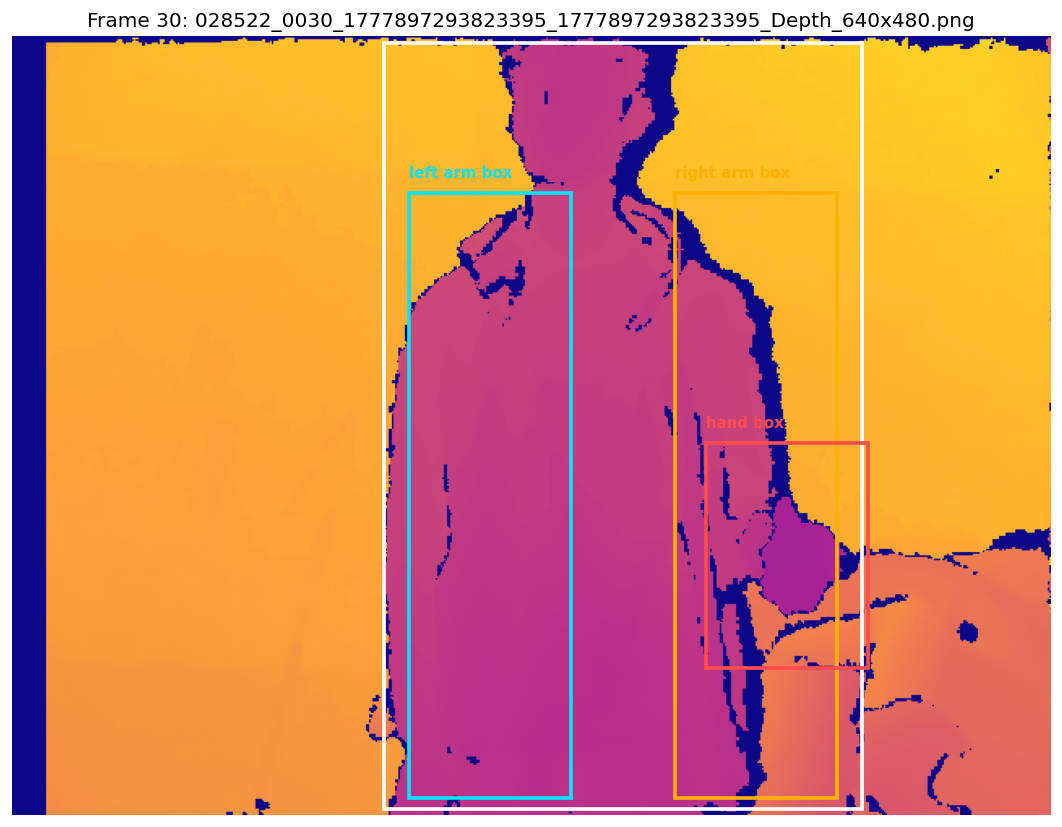

User box : (229, 4, 523, 476)
Left box : (244, 96, 344, 469)
Right box: (408, 96, 508, 469)
Hand box : (427, 250, 527, 389)
Foreground pixels: 87909


In [138]:
frame_idx = min(len(frames) // 3, len(frames) - 1)
left_box, right_box, hand_box, user_box, mask = plot_arm_boxes(
    frames[frame_idx],
    frame_title=f'Frame {frame_idx}: {frame_paths[frame_idx].name}'
)

print('User box :', user_box)
print('Left box :', left_box)
print('Right box:', right_box)
print('Hand box :', hand_box)
print(f'Foreground pixels: {int(mask.sum())}')


---
## 4. Review multiple frames

Use this to see whether the heuristic remains stable across the sequence.


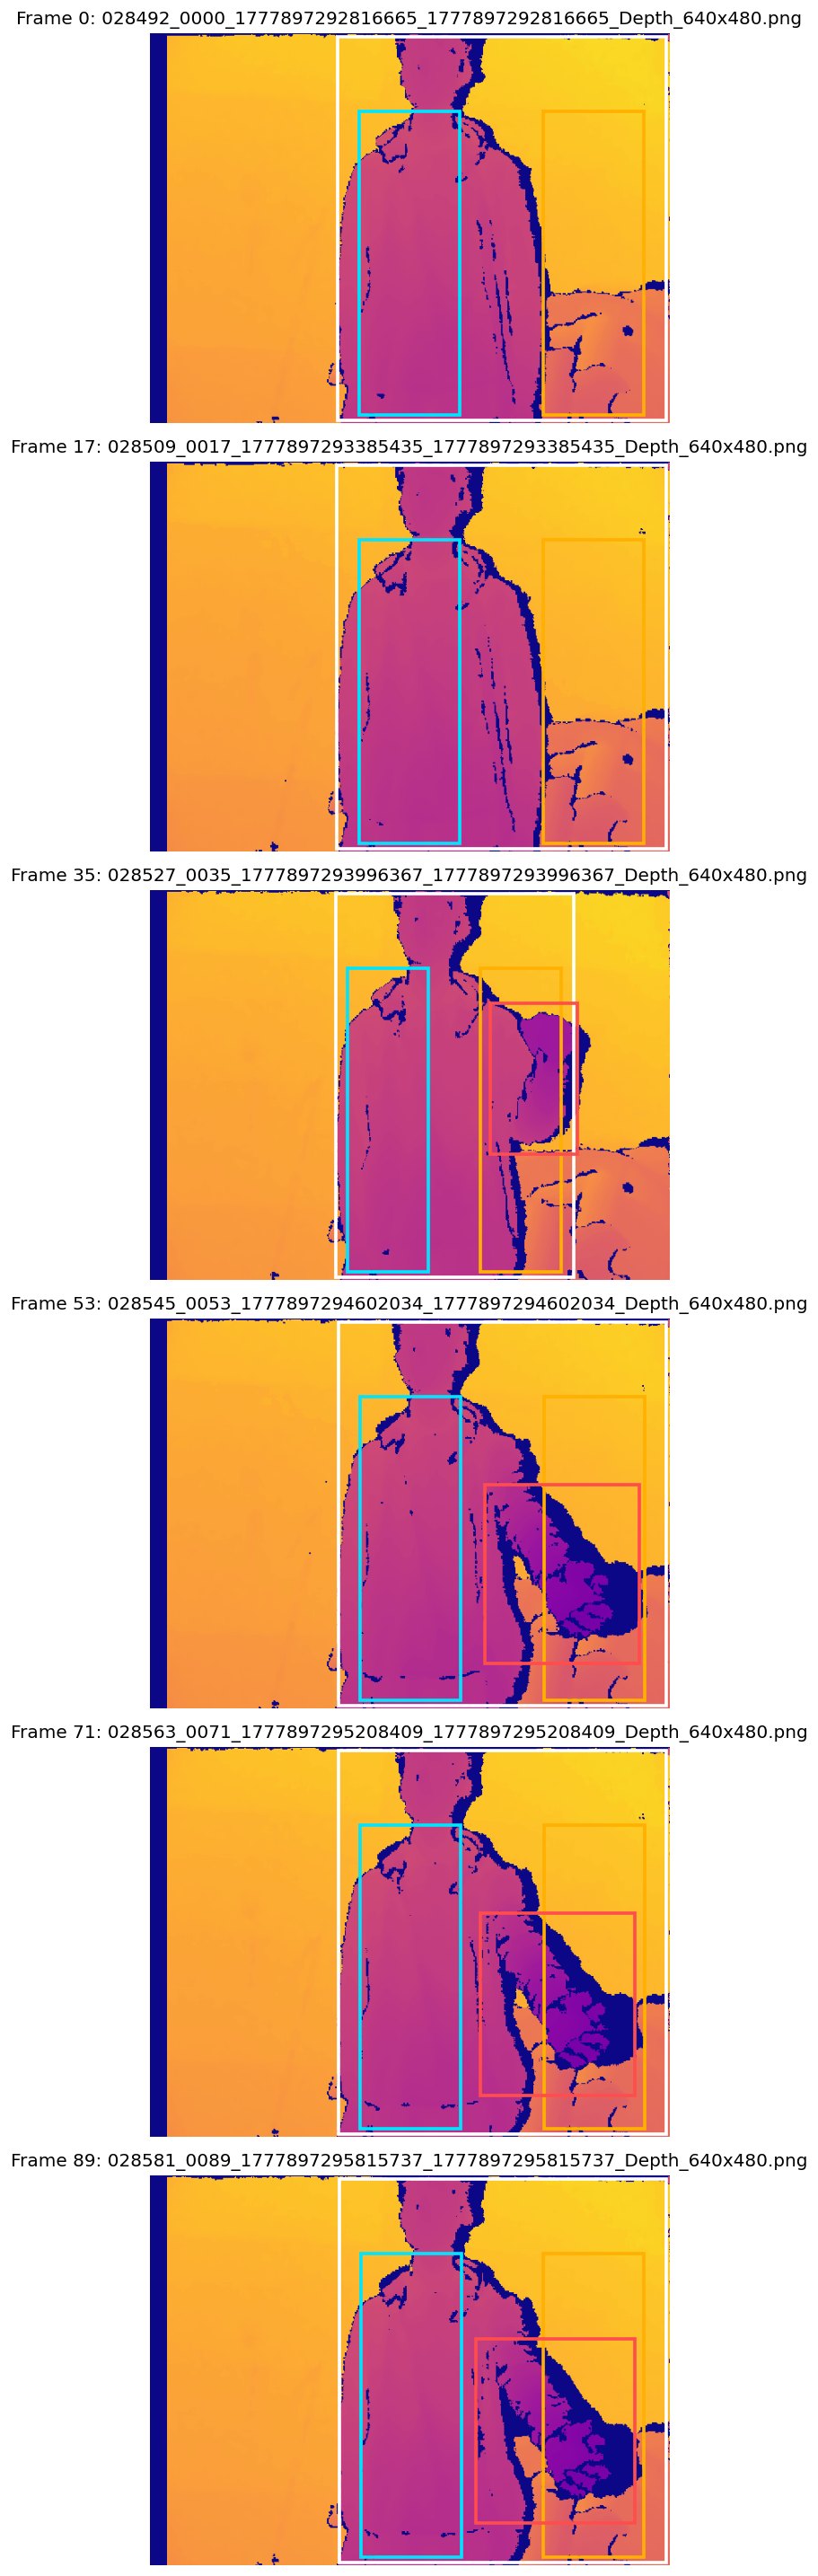

In [139]:
frame_indices = np.linspace(0, len(frames) - 1, num=min(6, len(frames)), dtype=int)
fig, axes = plt.subplots(len(frame_indices), 1, figsize=(10, 4 * len(frame_indices)))
if len(frame_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, frame_indices):
    depth = frames[idx]
    left_box, right_box, user_box, user_mask = estimate_arm_boxes(depth)
    hand_box, _, _ = estimate_hand_box(depth, user_box, user_mask)
    ax.imshow(depth, cmap='plasma')
    for bbox, color in [(user_box, '#FFFFFF'), (left_box, '#00E5FF'), (right_box, '#FFB000'), (hand_box, '#FF4D4D')]:
        if bbox is None:
            continue
        x1, y1, x2, y2 = bbox
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.2, edgecolor=color, facecolor='none'))
    ax.set_title(f'Frame {idx}: {frame_paths[idx].name}')
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 5. Export boxes if needed

If you want to reuse the annotations in another script, save them as JSON from this notebook.


In [140]:
output_path = Path('..') / 'customDataset' / f'{CLIP_DIR.name}' / f'{CLIP_DIR.name}_arm_boxes.json'
save_arm_annotations(CLIP_DIR, output_path)
print(f'Saved annotations to {output_path}')


Saved annotations to ..\customDataset\0504_2033_90\0504_2033_90_arm_boxes.json


---
## Notes

The heuristic is intentionally simple: it first extracts the whole-user silhouette, finds a tight full-user bounding box, uses the box center plus a horizontal offset ratio to place two slim arm boxes, trims the top portion of those boxes by a fixed fraction, and then adds a hand box by isolating the closest foreground component inside the user mask. If a clip needs more precise boxes, tune `USER_TOP_CROP_FRAC`, `USER_BOTTOM_TRIM_FRAC`, `ARM_LATERAL_OFFSET_FRAC`, `ARM_BOX_WIDTH_FRAC`, and the hand-threshold constants near the top of the notebook.
